### Autor: David Roca Tauste
---

# 1. Preparación
## Carga de librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import StandardScaler

from xgboost import XGBClassifier

## Carga de CSV i información

In [207]:
ruta = "Admission.csv"
datos = pd.read_csv(ruta, sep=";")

valor_objetivo = "admit"

In [208]:
print(datos.shape)
print(f"La cantidad de filas es: {datos.shape[0]}")
print(f"La cantidad de columnas es: {datos.shape[1]}")

(400, 7)
La cantidad de filas es: 400
La cantidad de columnas es: 7


In [209]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   admit        400 non-null    object 
 1   gre          400 non-null    int64  
 2   gpa          400 non-null    float64
 3   ses          400 non-null    int64  
 4   Gender_Male  400 non-null    int64  
 5   Race         400 non-null    int64  
 6   rank         400 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 22.0+ KB


In [210]:
datos.describe()

,gre,gpa,ses,Gender_Male,Race,rank
count,400.000000,400.000000,400.000000,400.000,400.000000,400.00000
mean,587.700000,3.389900,1.992500,0.475,1.962500,2.48500
std,115.516536,0.380567,0.808751,0.500,0.823279,0.94446
min,220.000000,2.260000,1.000000,0.000,1.000000,1.00000
25%,520.000000,3.130000,1.000000,0.000,1.000000,2.00000
50%,580.000000,3.395000,2.000000,0.000,2.000000,2.00000
75%,660.000000,3.670000,3.000000,1.000,3.000000,3.00000
max,800.000000,4.000000,3.000000,1.000,3.000000,4.00000


---
# 2. Limpieza de datos
## 2.1. Gestión de valores nulos

In [211]:
print("Número de casillas nulas:")
datos.isnull().sum()

Número de casillas nulas:


admit          0
gre            0
gpa            0
ses            0
Gender_Male    0
Race           0
rank           0
dtype: int64

## 2.2. Tipos de datos de las columnas

In [212]:
datos.dtypes

admit           object
gre              int64
gpa            float64
ses              int64
Gender_Male      int64
Race             int64
rank             int64
dtype: object

## 2.3. Gestión de anomalías (outliers)

In [213]:
columnas = datos.columns.values
print(columnas)

['admit' 'gre' 'gpa' 'ses' 'Gender_Male' 'Race' 'rank']


### 2.3.1 Validación de valores int

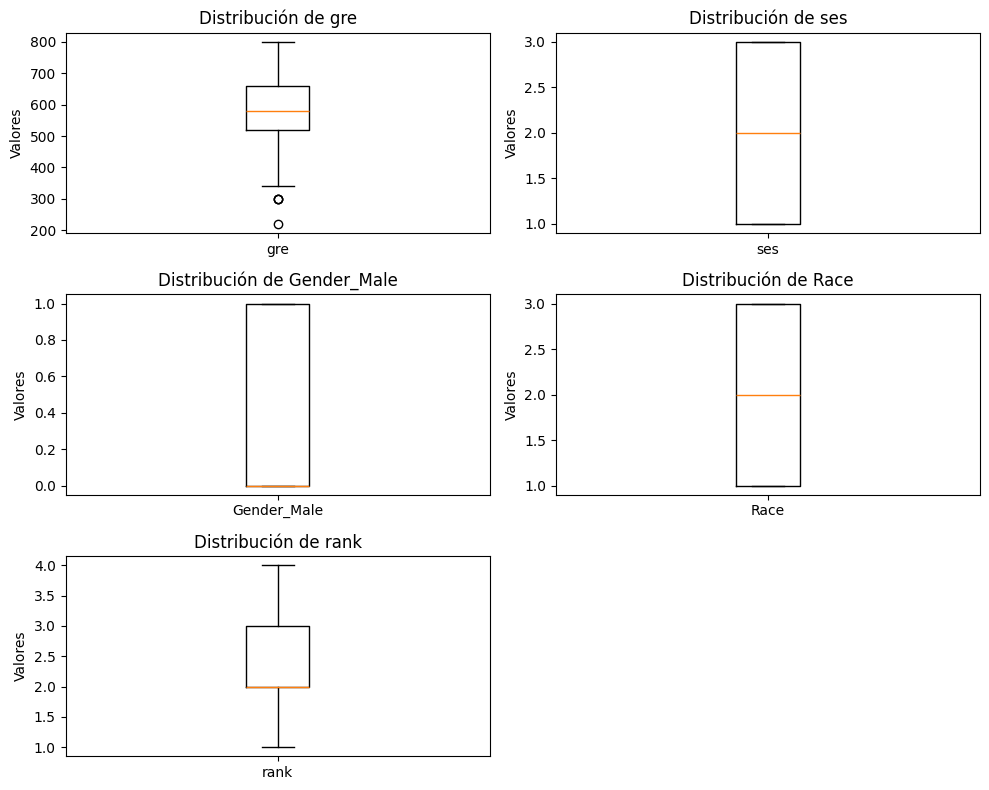

In [214]:
# Valores int
columnas_integer = []

for columna_actual in columnas:
    if (datos[columna_actual].dtype == "int64"):
        columnas_integer.append(columna_actual)
    

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))

axes = axes.flatten()
for i, var in enumerate(columnas_integer):
    axes[i].boxplot(datos[var], tick_labels=[var])
    axes[i].set_title(f'Distribución de {var}')
    axes[i].set_ylabel('Valores')

for j in range(len(columnas_integer), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [215]:
media = np.mean(datos["gre"].values)
desviacion = np.std(datos["gre"].values)
outliers = []

for elemento in datos["gre"].values:
    z = abs(elemento - media) / desviacion
    
    if z > 2:
        outliers.append(elemento)

print(len(outliers))
print(len(datos["gre"]))

8
400


In [216]:
datos = datos[~datos['gre'].isin(outliers)]

print(len(datos["gre"]))

392


### 2.3.2 Validación de valores object

In [217]:
columnas_objeto = datos.select_dtypes(include=['object']).columns

lista_columnas_objeto = list(columnas_objeto)
print(lista_columnas_objeto)

['admit']


In [218]:
for columna_actual in lista_columnas_objeto:
    conteo = datos.groupby(columna_actual).size()
    print(f"{conteo}\n")

admit
Admitt            2
Admitted        123
Not admitt        2
Not admitted    265
dtype: int64



In [219]:
datos['admit'] = datos['admit'].replace('Admitt', 'Admitted')
datos['admit'] = datos['admit'].replace('Not admitt', 'Not admitted')

print(datos['admit'].value_counts())

admit
Not admitted    267
Admitted        125
Name: count, dtype: int64


---
# 3. Ingeniería de características
## 3.1. Codificación de variables categóricas

In [220]:
datos.head()

,admit,gre,gpa,ses,Gender_Male,Race,rank
0,Not admitted,380,3.61,1,0,3,3
1,Admitted,660,3.67,2,0,2,3
2,Admitted,800,4.00,2,0,2,1
3,Admitted,640,3.19,1,1,2,4
4,Not admitted,520,2.93,3,1,2,4


In [221]:
datos['admit'] = datos['admit'].replace(["Admitted", "Not admitted"], [1, 0])

C:\Users\davil\AppData\Local\Temp\ipykernel_21300\4091653166.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos['admit'] = datos['admit'].replace(["Admitted", "Not admitted"], [1, 0])


In [222]:
datos.head()

,admit,gre,gpa,ses,Gender_Male,Race,rank
0,0,380,3.61,1,0,3,3
1,1,660,3.67,2,0,2,3
2,1,800,4.00,2,0,2,1
3,1,640,3.19,1,1,2,4
4,0,520,2.93,3,1,2,4


## 3.2. Escalado

In [223]:
se = StandardScaler()

for columna in columnas:
    if (columna != "admit"):
        datos[columna] = se.fit_transform(datos[[columna]])

In [224]:
datos.head()

,admit,gre,gpa,ses,Gender_Male,Race,rank
0,0,-1.952182,0.557857,-1.231148,-0.950217,1.256721,0.548146
1,1,0.609648,0.716455,0.006314,-0.950217,0.037328,0.548146
2,1,1.890563,1.588742,0.006314,-0.950217,0.037328,-1.568833
3,1,0.426660,-0.552328,-1.231148,1.052391,0.037328,1.606636
4,0,-0.671267,-1.239585,1.243775,1.052391,0.037328,1.606636


---
# 4. Análisis exploratorio de datos

Text(0.5, 1.0, 'Distribución de valores de admit')

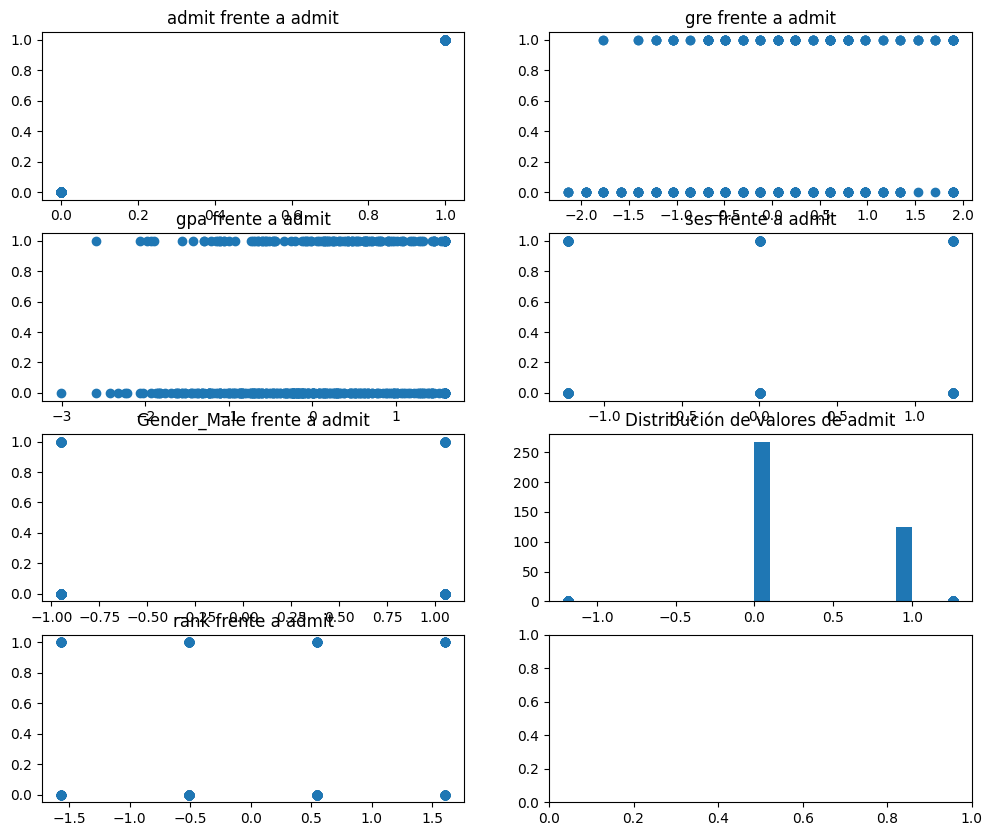

In [225]:
fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(12, 10))

for i in range(0, len(columnas)):
    fila = i // 2
    columna = i % 2
    ax[fila, columna].scatter(x = datos[columnas[i]], y = datos[valor_objetivo])
    ax[fila, columna].set_title(columnas[i] + " frente a " + valor_objetivo)
    
ax[2, 1].hist(datos[valor_objetivo], bins=10)
ax[2, 1].set_title("Distribución de valores de " + valor_objetivo)

---
# 5. Desarrollo de un modelo supervisado de clasificación

Hemos elegido relizar un modelo supervisado de clasificación debido a que el valor objetivo se trata de un booleano, ya que solo puede ser admitido o no admitido.

## 5.1. Elección del modelo
Debido al tiempo limitado, hemos elegido para realizar la prueba dos modelos: `RandomForestClassifier` y `XGBClassifier`.

## 5.2. Preparación de los conjuntos train y test

In [226]:
X = datos.drop(valor_objetivo,axis=1)
y = datos[valor_objetivo]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [227]:
def train_validation(model):
    model.fit(X_train, y_train.astype(int))
    y_pred = model.predict(X_test)
    conf_matrix = confusion_matrix(y_pred, y_test)

    print(classification_report(y_pred, y_test.astype(int)))
    print("score_test = ", model.score(X_test, y_test.astype(int)))
    print("score_train = ", model.score(X_train, y_train.astype(int)))

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No admitido", "Admitido"],
        yticklabels=["No admitido", "Admitido"],
    )
    plt.title("Matriz de Confusión")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

              precision    recall  f1-score   support

           0       0.83      0.79      0.81        43
           1       0.50      0.56      0.53        16

    accuracy                           0.73        59
   macro avg       0.66      0.68      0.67        59
weighted avg       0.74      0.73      0.73        59

score_test =  0.7288135593220338
score_train =  1.0


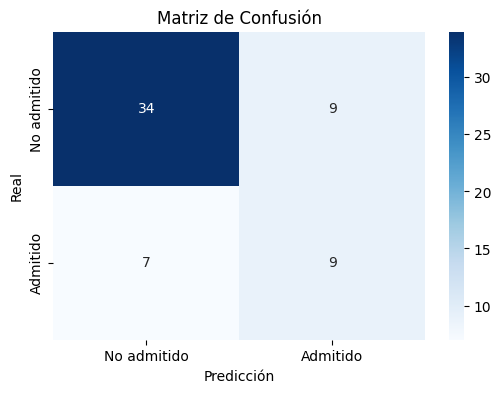

In [228]:
# Modelo 1: RandomForestClassifier
model = RandomForestClassifier(random_state=42, n_estimators=100)
train_validation(model)

              precision    recall  f1-score   support

           0       0.80      0.75      0.78        44
           1       0.39      0.47      0.42        15

    accuracy                           0.68        59
   macro avg       0.60      0.61      0.60        59
weighted avg       0.70      0.68      0.69        59

score_test =  0.6779661016949152
score_train =  0.9069069069069069


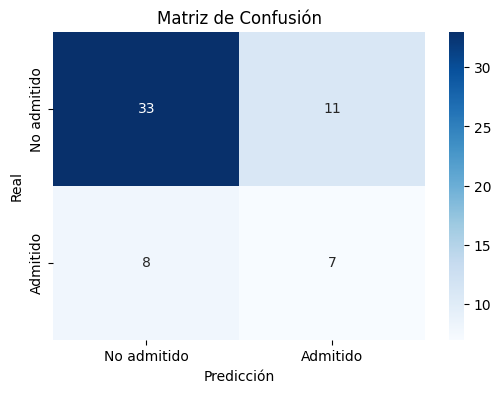

In [229]:
# Modelo 2: XGBClassifier
model = XGBClassifier(max_depth=5, learning_rate=0.1, n_estimators=100, gamma=0.3)

model.fit(X_train, y_train)
train_validation(model)

---
# Conclusiones

A partir de las métricas obtenidas de los dos modelos, hemos llegado a la conclusión de que ningún modelo podría ser usado. Para llegar a esta conclusión, nos hemos basado en la métrica "f1-score", debido a que las clases están desequilibradas y se necesita un compromiso entre precisión y exhaustividad.

- En cuanto al modelo `RandomForestClassifier`: los resultados son 0'81 para 0 y 0'53 para 1.
- En cuanto al modelo `XGBClassifier`: los resultados son 0'78 para 0 y 0'42 para 1.

Estas métricas indican que los modelos no son eficaces, debido a su bajo valor sobre 1. Otro motivo es que, debido al desbalanceo de las dos clase del valor objetivo, el modelo se inclina demasiado hacia los verdaderos positivos.

Con una mayor cantidad de tiempo, se podrían realizar varias mejoras, tales como un balanceo de los datos, la prueba de una mayor cantidad de modelos o la realización de otras técnicas que nos sirvieran de ayuda.